## 7. Tratamiento de Datos Faltantes

En esta etapa del análisis se realizó la identificación, evaluación y tratamiento de los valores faltantes presentes en el conjunto de datos, con el objetivo de garantizar la calidad de la información antes de continuar con el modelado o análisis exploratorio.

Se importaron las librerías necesarias para la manipulación, análisis y visualización de datos:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Interpretación

Estas librerías permiten la gestión eficiente de datos estructurados (Pandas y NumPy) y la generación de visualizaciones (Matplotlib y Seaborn)

7.1 Identificación de Datos Faltantes

Se realizó la carga del conjunto de datos y se evaluó la presencia de valores nulos por variable: 

In [2]:
df = pd.read_csv("water_potability_clean.csv")

In [3]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

El análisis de valores faltantes muestra que las variables con datos ausentes son Sulfate (781 registros), pH (491 registros) y Trihalomethanes (162 registros). Las demás variables no presentan valores nulos, por lo que mantienen la totalidad de los registros disponibles para el análisis.

7.2 Definición del umbral de eliminación

Se estableció un umbral del 5% del total de registros del dataset:

In [4]:
umbral = len(df) * 0.05

Interpretación:

El cálculo del umbral establece el 5% del total de registros del dataset como criterio para evaluar el tratamiento de valores faltantes. Este valor permite identificar si una variable tiene una cantidad significativa de datos ausentes y definir si es necesario aplicar estrategias como imputación o eliminación.

7.3 Selección de variables con pocos valores faltantes

Se seleccionaron las variables cuyo número de valores faltantes era menor o igual al umbral establecido:

In [5]:
cols_to_drop = df.columns[df.isna().sum() <= umbral]

Interpretación:

Las variables seleccionadas presentan una cantidad baja de valores faltantes, lo que permite su tratamiento mediante eliminación de registros sin afectar de forma significativa la calidad del análisis ni la representatividad del conjunto de datos.

7.4 Eliminación de registros con valores faltantes

Se eliminaron los registros que contenían valores faltantes en las variables seleccionadas:

In [6]:
df.dropna(subset=cols_to_drop, inplace=True)

Interpretación:

Esta instrucción elimina del dataset todas las filas que contienen valores nulos en las columnas seleccionadas previamente (cols_to_drop). Al usar inplace=True, los cambios se aplican directamente sobre el DataFrame original, asegurando que el conjunto de datos quede limpio y listo para el análisis sin registros incompletos en esas variables.

7.5 Comparación de distribuciones

Para evaluar el impacto de la eliminación de registros, se compararon las distribuciones de las variables con datos faltantes antes y después del tratamiento.

In [7]:
df_original = pd.read_csv("water_potability_clean.csv")
df = df_original.copy()

umbral = len(df) * 0.05
cols_to_drop = df.columns[df.isna().sum() <= umbral]

df.dropna(subset=cols_to_drop, inplace=True)

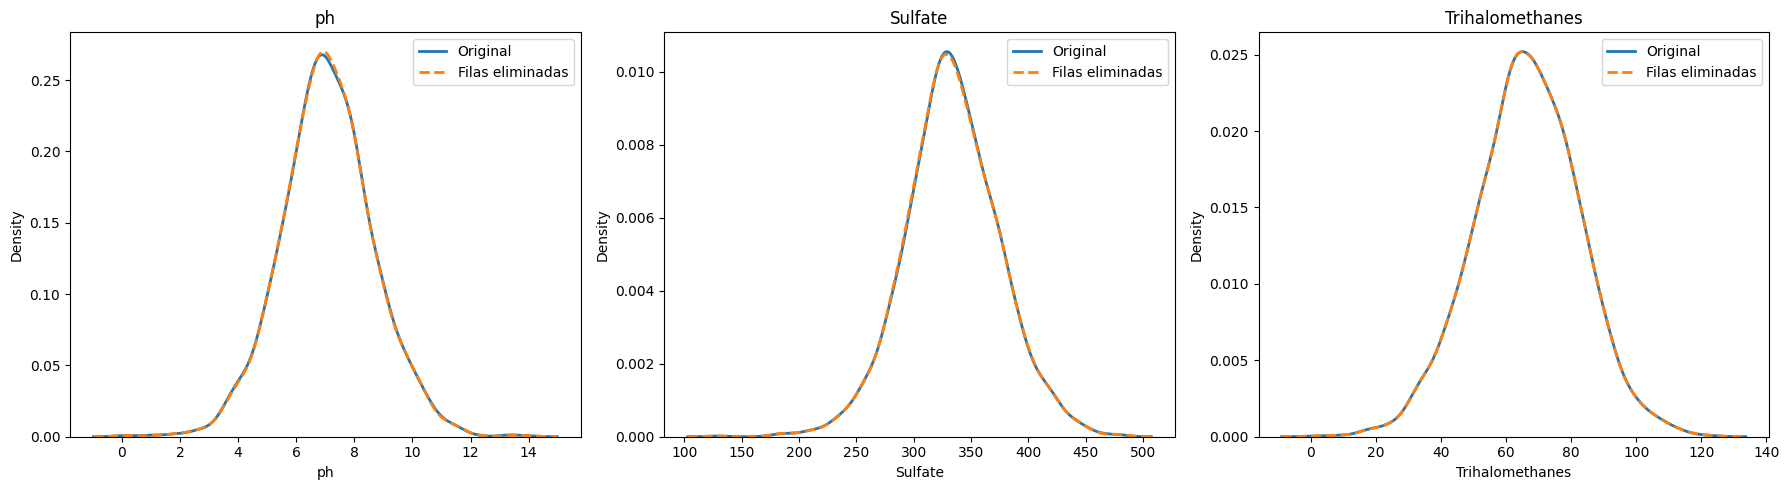

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['ph', 'Sulfate', 'Trihalomethanes']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(variables):

    sns.kdeplot(
        df_original[var].dropna(),
        label='Original',
        linewidth=2,
        ax=axes[i]
    )

    sns.kdeplot(
        df[var].dropna(),
        label='Filas eliminadas',
        linewidth=2,
        linestyle='--',
        ax=axes[i]
    )

    axes[i].set_title(var)
    axes[i].legend()

plt.tight_layout()
plt.show()

Las distribuciones de las variables pH, Sulfate y Trihalomethanes se mantienen prácticamente iguales después de eliminar los valores nulos. Esto indica que la eliminación de registros no generó un sesgo significativo ni alteró la forma de las distribuciones, por lo que el proceso de limpieza fue adecuado y no afectó el comportamiento general de los datos.

7.6 Validación mediante la prueba KS

Se aplicó la prueba KS para comparar estadísticamente las distribuciones antes y después del tratamiento:

In [9]:
from scipy.stats import ks_2samp

variables = ['ph', 'Sulfate', 'Trihalomethanes']

for var in variables:

    stat, p_value = ks_2samp(
        df_original[var].dropna(),
        df[var].dropna()
    )

    print(f"\nPrueba KS para '{var}'")
    print("Estadístico KS:", round(stat, 4))
    print("Valor p:", round(p_value, 4))

    if p_value < 0.05:
        print("✅Existen diferencias significativas.")
    else:
        print("❌No se encontraron diferencias significativas.")


Prueba KS para 'ph'
Estadístico KS: 0.003
Valor p: 1.0
❌No se encontraron diferencias significativas.

Prueba KS para 'Sulfate'
Estadístico KS: 0.0042
Valor p: 1.0
❌No se encontraron diferencias significativas.

Prueba KS para 'Trihalomethanes'
Estadístico KS: 0.0
Valor p: 1.0
❌No se encontraron diferencias significativas.


Resultados

pH → p-value = 1.0

Sulfate → p-value = 1.0

Trihalomethanes → p-value = 1.0


Interpretación

En todos los casos, el valor p fue mayor a 0.05, por lo que no se encontraron diferencias estadísticamente significativas entre las distribuciones originales y las distribuciones tras el tratamiento.

Esto indica que la eliminación de registros no alteró de forma significativa el comportamiento de las variables analizadas, es decir, la forma general de las distribuciones se mantiene estable antes y después del proceso de depuración de datos.

Adicionalmente, los estadísticos KS cercanos a 0 refuerzan esta conclusión, evidenciando que no hubo cambios relevantes en la estructura de los datos, lo cual sugiere que el tratamiento aplicado fue conservador y no introdujo sesgos ni distorsiones en las variables evaluadas.